## Subsampling with `Subsample`

**Subsampling** (also called *thinning*) reduces the number of data points that are passed to a plotting method by selecting a regular subset of the source grid. No new values are computed — only existing grid points are used. This is the simplest and fastest way to reduce overcrowding in vector plots (arrows, barbs) or scatter-style plots.

Use `Subsample` when:
- you have a **dense grid** and only need a representative thinned sample,
- you want to **preserve exact source values** (no interpolation), or
- you need a quick density reduction without adding a dependency on scipy or earthkit-geo.

`Subsample` offers two modes:
- **`'stride'`** — skip every *n* grid points in x and y.
- **`'fixed'`** (default) — select approximately *n* evenly-spaced points in x and y.

For smooth, interpolated upsampling or projection-aligned resampling, see [Bilinear](resampling-bilinear.ipynb).

### Example: Wind vectors from Storm Ophelia

We use wind data from Storm Ophelia (October 2017) — a dense regular lat/lon grid that benefits from thinning before plotting wind arrows.

In [1]:
import earthkit.data as ekd

import earthkit.plots as ekp

data = ekd.from_source("sample", "storm_ophelia_wind_850.grib").to_fieldlist()
data.ls()

storm_ophelia_wind_850.grib:   0%|          | 0.00/34.0k [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,u,2017-10-16,2017-10-16,0 days,850,pressure,0,regular_ll
1,v,2017-10-16,2017-10-16,0 days,850,pressure,0,regular_ll


### Stride mode

In `mode='stride'`, the argument is the **step size** — `Subsample(1, mode='stride')` plots every grid point (no thinning), while `Subsample(4, mode='stride')` plots every 4th point in both x and y.

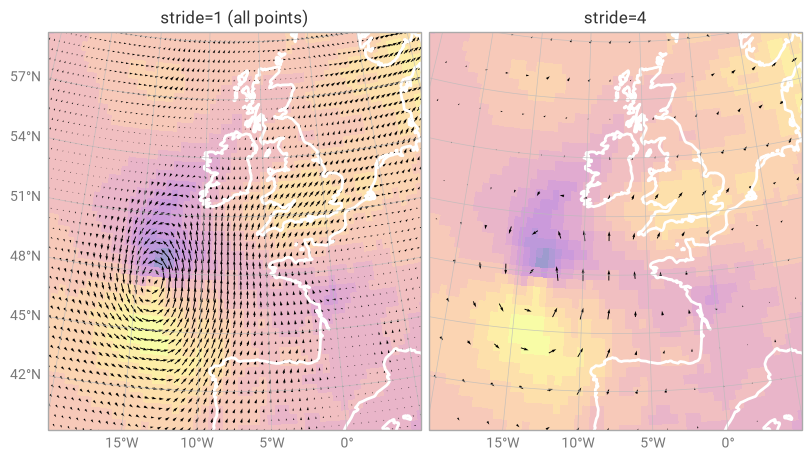

In [2]:
from earthkit.plots.resample import Subsample

figure = ekp.Figure(rows=1, columns=2, domain=[-20, 5, 40, 60])

# Every grid point
ax = figure.add_map()
ax.grid_cells(data[0], alpha=0.4)
ax.quiver(data, resample=Subsample(1, mode="stride"))
ax.title("stride=1 (all points)")

# Every 4th point
ax = figure.add_map()
ax.grid_cells(data[0], alpha=0.4)
ax.quiver(data, resample=Subsample(4, mode="stride"))
ax.title("stride=4")

figure.coastlines(color="white", linewidth=2)
figure.gridlines()

figure.show()

You can also set different strides in x and y with the `nx` and `ny` keyword arguments.

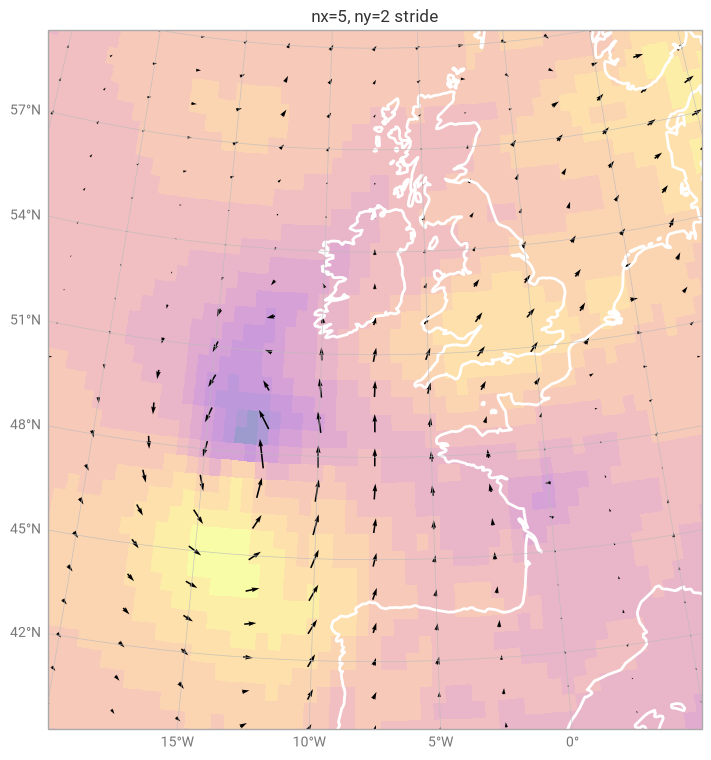

In [3]:
chart = ekp.Map(domain=[-20, 5, 40, 60])

chart.grid_cells(data[0], alpha=0.4)

# Every 5th point in x, every 2nd point in y
chart.quiver(data, resample=Subsample(nx=5, ny=2, mode="stride"))

chart.coastlines(color="white", linewidth=2)
chart.gridlines()
chart.title("nx=5, ny=2 stride")

chart.show()

### Fixed mode

In `mode='fixed'` (the default), the argument is the **target number of points** in each direction. Points are selected to be as evenly spread as possible across the grid.

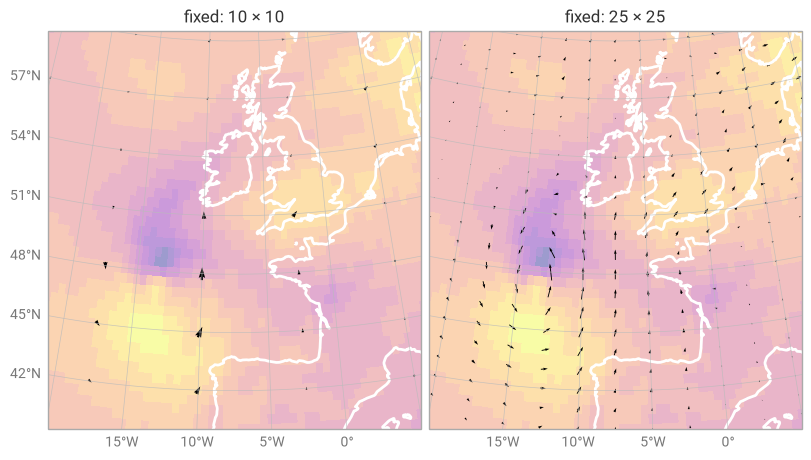

In [4]:
figure = ekp.Figure(rows=1, columns=2, domain=[-20, 5, 40, 60])

# ~10 points in each direction
ax = figure.add_map()
ax.grid_cells(data[0], alpha=0.4)
ax.quiver(data, resample=Subsample(10, mode="fixed"))
ax.title("fixed: 10 × 10")

# ~25 points in each direction
ax = figure.add_map()
ax.grid_cells(data[0], alpha=0.4)
ax.quiver(data, resample=Subsample(25, mode="fixed"))
ax.title("fixed: 25 × 25")

figure.coastlines(color="white", linewidth=2)
figure.gridlines()

figure.show()

<div class="alert alert-block alert-info">
<strong>NOTE:</strong> <code>mode='fixed'</code> gives an <em>approximate</em> target — the exact count depends on divisibility with the source grid size. The selection is always evenly spaced. If you request more points than exist in the source, all source points are returned (Subsample never interpolates).
</div>

### Asymmetric subsampling

You can specify different targets for x and y with `nx` and `ny`. This is useful when the source grid has very different aspect ratios, or when you want a deliberately sparser sampling in one direction.

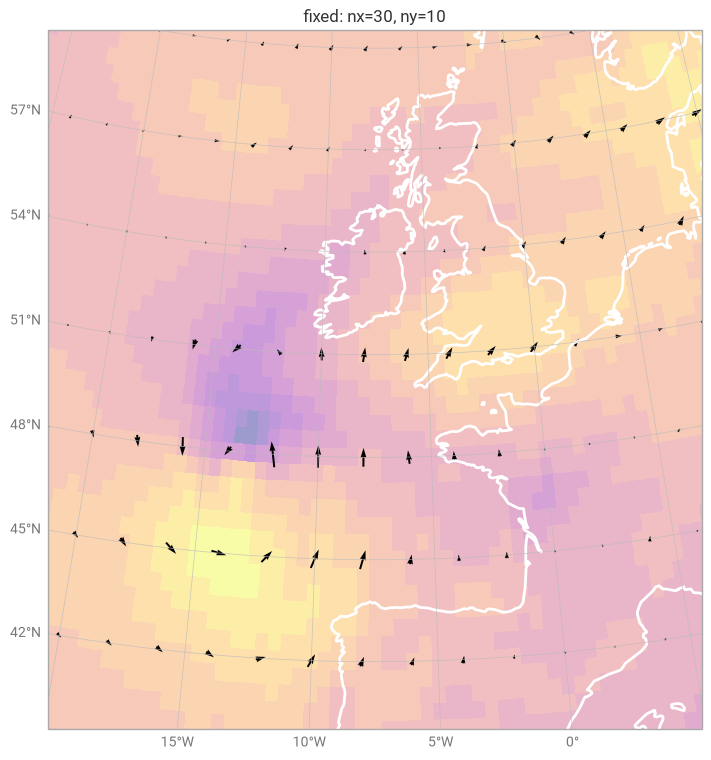

In [5]:
chart = ekp.Map(domain=[-20, 5, 40, 60])

chart.grid_cells(data[0], alpha=0.4)

# More points in x than y
chart.quiver(data, resample=Subsample(nx=30, ny=10, mode="fixed"))

chart.coastlines(color="white", linewidth=2)
chart.gridlines()
chart.title("fixed: nx=30, ny=10")

chart.show()